# Day 047 — Bias-Variance Tradeoff & Learning Curves
**AI/ML 365-Day Roadmap — Sahil Kumar**

---

## 1. Bias-Variance Decomposition

Every model's **Total Prediction Error** can be broken down into three components:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise (σ²)}$$

### What Each Term Means:

| Term | Definition | Intuition |
|---|---|---|
| **Bias** | Error from wrong/simplistic assumptions in the model | Model is too simple to capture the true pattern |
| **Variance** | Error from sensitivity to small fluctuations in training data | Model memorizes training noise instead of learning the signal |
| **Irreducible Noise** | Inherent randomness in data that NO model can capture | Bad data, measurement errors, missing features |

### Key Insight:
- You can **never** remove irreducible noise
- Reducing bias often increases variance (and vice versa) → this is the **tradeoff**
- The goal is to find the **sweet spot** where total error is minimized

---

## 2. Underfitting vs Overfitting

| Aspect | Underfitting (High Bias) | Overfitting (High Variance) | Good Fit |
|---|---|---|---|
| **Train Error** | ❌ High | ✅ Very Low (~0) | ✅ Low |
| **Validation Error** | ❌ High | ❌ High | ✅ Low |
| **Gap (Train - Val)** | Small (both bad) | Large (train good, val bad) | Small (both good) |
| **Model Complexity** | Too simple | Too complex | Just right |
| **Examples** | Linear model on non-linear data | Decision Tree with no max_depth | Tuned Random Forest |

### How to Diagnose:
1. **Both errors high** → Underfitting (High Bias)
2. **Train error low, Val error high** → Overfitting (High Variance)
3. **Both errors low, small gap** → Good Fit ✅

---

## 3. Learning Curves

**What**: Plot **Training Error** and **Validation Error** as a function of **Training Set Size**

**Why**: To diagnose whether your model suffers from bias or variance

### Reading Learning Curves:

#### Case 1: High Bias (Underfitting)
- Both curves **converge at a HIGH error** value
- Adding more data **WON'T help** — the model is too simple
- Fix: Use more complex model, add features, reduce regularization

#### Case 2: High Variance (Overfitting)
- **Large gap** between train (low) and val (high) curves
- Adding more data **WILL help** — curves slowly converge
- Fix: Regularization, simpler model, dropout, pruning

#### Case 3: Good Fit
- Both curves converge at a **LOW error** value
- Small gap between train and val

### Sklearn Syntax:
```python
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator,              # Your model or Pipeline
    X, y,
    cv=5,                   # Cross-validation folds
    scoring='accuracy',     # Metric to evaluate
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10%, 20%, ..., 100% of data
    n_jobs=-1               # Parallel processing
)
# Returns: train_sizes (array), train_scores (n_sizes × n_folds), val_scores (n_sizes × n_folds)
# Use .mean(axis=1) and .std(axis=1) for plotting
```

---

## 4. Validation Curves

**What**: Plot **Training Error** and **Validation Error** as a function of a **Hyperparameter Value**

**Why**: To find the optimal value of a hyperparameter (e.g., max_depth, C, n_estimators)

### Reading Validation Curves:
- **Left side** (low complexity): High bias → both errors high
- **Right side** (high complexity): High variance → train error drops, val error rises
- **Sweet spot**: Where validation error is lowest

### Sklearn Syntax:
```python
from sklearn.model_selection import validation_curve

train_scores, val_scores = validation_curve(
    estimator,               # Your model
    X, y,
    param_name='max_depth',  # Name of hyperparameter to vary
    param_range=[1, 2, 3, 5, 7, 10, 15, 20],  # Values to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
```

---

## 5. Mitigation Strategies Summary

| Problem | Strategies |
|---|---|
| **High Bias** | ↑ Model complexity, ↑ features/polynomial features, ↓ regularization, use non-linear models |
| **High Variance** | ↑ Training data, ↑ regularization (L1/L2, dropout), ↓ model complexity, use ensembles, early stopping |

### Important Rule:
- **More data helps VARIANCE problems, NOT bias problems**
- If your model is too simple, no amount of data will fix it
- Always plot learning curves BEFORE blindly tuning hyperparameters

---

## 🧪 Practice Tasks

1. Generate a classification dataset using `make_classification(n_samples=2000, n_features=20, n_informative=10, flip_y=0.1)`
2. Plot **learning curves** for:
   - `LogisticRegression()` → should show High Bias
   - `DecisionTreeClassifier(max_depth=None)` → should show High Variance
   - `RandomForestClassifier(n_estimators=100, max_depth=10)` → should show Good Fit
3. Plot **validation curves** for:
   - `DecisionTreeClassifier` with `param_name='max_depth'`, `param_range=[1,2,3,5,7,10,15,20,30]`
   - `RandomForestClassifier` with `param_name='n_estimators'`, `param_range=[10,25,50,75,100,150,200,300]`
4. Use `plt.fill_between()` to show ±1 std deviation bands
5. Print the **gap** (train_acc - val_acc) as overfitting signal

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import make_classification

In [6]:
from sklearn.linear_model import LogisticRegression

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.model_selection import learning_curve,validation_curve

In [11]:
X,y=make_classification(n_samples=2000,n_features=20,n_informative=10,flip_y=0.1,random_state=42)

In [19]:
def plot_lc(estimator,name):
    train_sizes,train_score,val_score=learning_curve(
        estimator,X,y,random_state=42,cv=5,scoring='accuracy',train_sizes=np.linspace(0.1,1.0,10),n_jobs=-1)
    train_mean,train_sd=train_score.mean(axis=1),train_score.std(axis=1)
    val_mean,val_sd=val_score.mean(axis=1),val_score.std(axis=1)
    gap=train_mean[-1]-val_mean[-1]
    print(f"[{name}] Train_acc= {train_mean[-1]:.4f} Val_acc= {val_mean[-1]:.4f} gap={gap:.4f}")
    plt.figure(figsize=(8, 4))
    plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Train Score')
    plt.plot(train_sizes, val_mean, 'o-', color='#2ecc71', label='Validation Score')
    
    # ±1 Std Deviation Shaded Bands
    plt.fill_between(train_sizes, train_mean - train_sd, train_mean + train_sd, alpha=0.15, color='#e74c3c')
    plt.fill_between(train_sizes, val_mean - val_sd, val_mean + val_sd, alpha=0.15, color='#2ecc71')
    
    plt.title(f"Learning Curve — {name}", fontweight='bold')
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

[Logistic] Train_acc= 0.8129 Val_acc= 0.8070 gap=0.0059


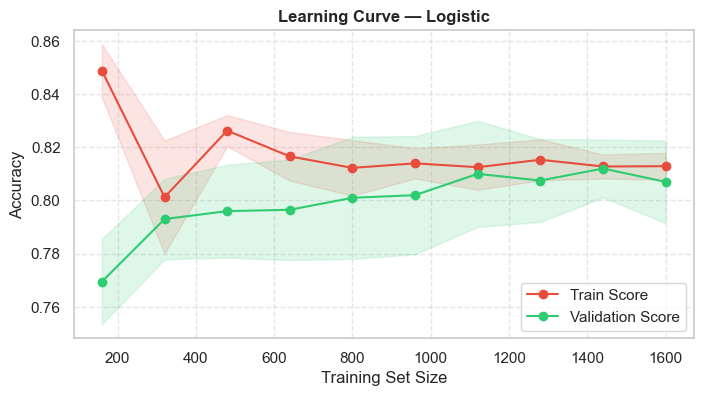

In [20]:
plot_lc(LogisticRegression(max_iter=1000),"Logistic")

[Decision] Train_acc= 1.0000 Val_acc= 0.7455 gap=0.2545


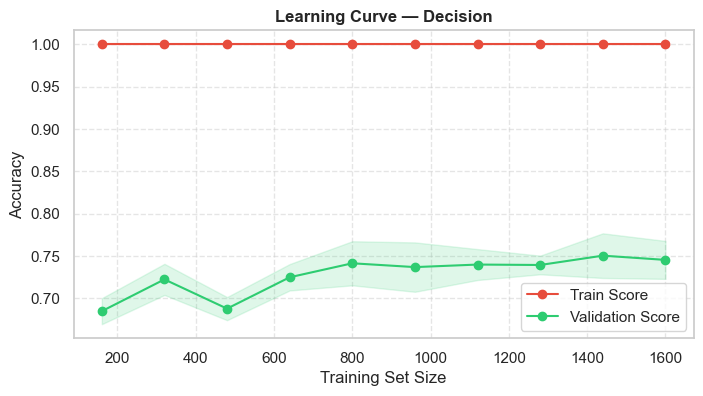

In [26]:
plot_lc(DecisionTreeClassifier(random_state=42,max_depth=None),"Decision")

[Random] Train_acc= 0.9858 Val_acc= 0.8600 gap=0.1258


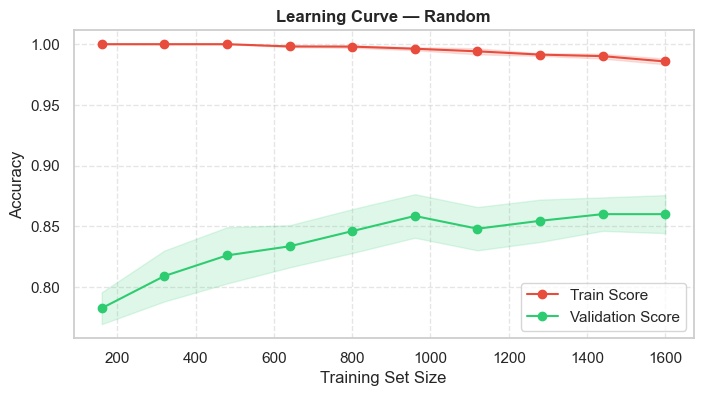

In [27]:
plot_lc(RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42),"Random")

In [30]:
def plot_vc(estimator,param_name,param_range,title):
    train_score,val_score=validation_curve(estimator,X,y,param_name=param_name,param_range=param_range,cv=5,scoring='accuracy',n_job=-1)
    train_mean,train_sd=train_score.mean(axis=1),train_score.std(axis=1)
    val_mean,val_sd=val_score.mean(axis=1),val_score.std(axis=1)
    plt.figure(figsize=(8,4))
    plt.plot(param_range, train_mean, 'o-', color='#e74c3c', label='Train Score')
    plt.plot(param_range, val_mean, 'o-', color='#2ecc71', label='Validation Score')
    plt.fill_between(param_range,train_mean-train_sd,train_mean+train_sd,alpha=0.15,color='#e74c3c')
    plt.fill_between(param_range, val_mean - val_sd, val_mean + val_sd, alpha=0.15, color='#2ecc71')

In [31]:
def plot_vc(estimator, param_name, param_range, title):
    train_score, val_score = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    
    train_mean, train_sd = train_score.mean(axis=1), train_score.std(axis=1)
    val_mean, val_sd = val_score.mean(axis=1), val_score.std(axis=1)
    
    plt.figure(figsize=(8, 4))
    plt.plot(param_range, train_mean, 'o-', color='#e74c3c', label='Train Score')
    plt.plot(param_range, val_mean, 'o-', color='#2ecc71', label='Validation Score')
    
    plt.fill_between(param_range, train_mean - train_sd, train_mean + train_sd, alpha=0.15, color='#e74c3c')
    plt.fill_between(param_range, val_mean - val_sd, val_mean + val_sd, alpha=0.15, color='#2ecc71')
    
    plt.title(f"Validation Curve — {title}", fontweight='bold')
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

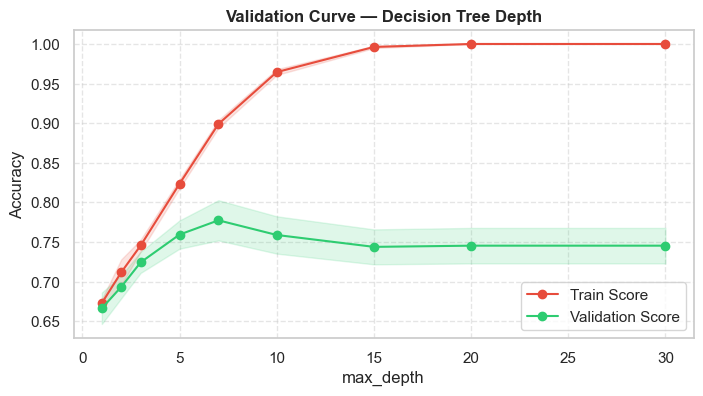

In [32]:
plot_vc(DecisionTreeClassifier(random_state=42), 'max_depth', [1, 2, 3, 5, 7, 10, 15, 20, 30], "Decision Tree Depth")

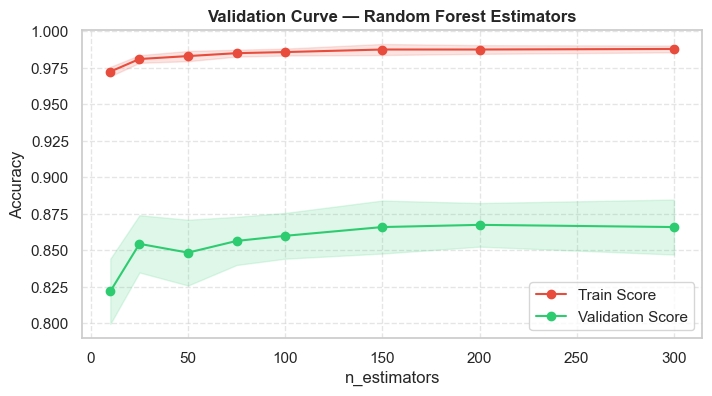

In [33]:
plot_vc(RandomForestClassifier(max_depth=10, random_state=42), 'n_estimators', [10, 25, 50, 75, 100, 150, 200, 300], "Random Forest Estimators")